# 2. Sensivity analysis

## 2.4 Test #4 for Diffusion coefficient perturbation

Model will be executed with *ANOTHER* 300 different version of the same input parameter, but there are a variation of origin location:

*Master input data:*
```yaml
   input:
    sim_diffusion_coeff: 10.0
    
```
The perturbated data in this test will be 100 different test into 1-20 variation

In [ ]:
import yaml
import os

# The base configuration structure
base_config = {
    'input': {
        'dataset_file_name': 'HECO_TEST.nc',
        'lat0': 40.5,
        'lon0': 10.5,
        'sim_diffusion_coeff': 10.0,
        'sim_duration_h': 72.0,
        'sim_particles': 100.0,
        'sim_timedelta_s': 3600.0,
        'spill_release_duration_h': 6.0,
        'time0': '2025-03-08 00:00:00',
        'volume_spilled_m3': 1000.0
    }
}

# Create a directory to store the generated YAML files
output_dir = "sa_2_4/input_yaml_files"
os.makedirs(output_dir, exist_ok=True)

# Create the base test file with the initial configuration
file_name = os.path.join(output_dir, "sa_2_4_test_0.yaml")
with open(file_name, 'w') as yaml_file:
    yaml.dump(base_config, yaml_file, default_flow_style=False, sort_keys=False)

num_tests = 100
for i in range(1, num_tests):
    diffusion_coeff = 1.0 + (20.0 - 1.0) * i / max(num_tests - 1, 1)
    base_config['input']['sim_diffusion_coeff'] = diffusion_coeff

    file_name = os.path.join(output_dir, f"sa_2_4_test_{i}.yaml")
    with open(file_name, 'w') as yaml_file:
        yaml.dump(base_config, yaml_file, default_flow_style=False, sort_keys=False)

print(f"Generated {num_tests} YAML files in {output_dir}.")

In [ ]:
import heco
import os
import geopandas as gpd
# Run 300 tests generated before
output_dir = "sa_2_4/heco_results"

os.makedirs(output_dir, exist_ok=True)
# input config files folder
for i in range(num_tests):
    config_file = f"sa_2_4/input_yaml_files/sa_2_4_test_{i}.yaml"
    output = heco.run(config_file)
    
    # Save result to csv
    # output path
    csv_dir = os.path.join(output_dir, 'csv')
    os.makedirs(csv_dir, exist_ok=True)
    csv_path = os.path.join(csv_dir, f'heco_results_test_{i}.csv')
    output.to_csv(csv_path, index=False)

    # Save point to geojson with geopandas
    gdf = gpd.GeoDataFrame(output, geometry=gpd.points_from_xy(output.lon, output.lat))
    gdf.crs = "EPSG:4326"
    geojson_dir = os.path.join(output_dir, 'geojson')
    os.makedirs(geojson_dir, exist_ok = True)
    geojson_path = os.path.join(geojson_dir, f'heco_results_test_{i}.geojson')
    gdf.to_file(geojson_path, driver='GeoJSON')

    print(f'Simulation results for test {i} saved to {csv_path} and {geojson_path}')

    heco.create_points_animation(geojson_path, f'sa_2_4/heco_results_test_{i}.gif')
    heco.multitimestamp_plot(output, 6)
    # export webmap

    heco.create_webmap(
        HECOpoint_output_gdf_path = geojson_path,
        EMODnetLayers = True,
        settingsFile_path = config_file,
        output_path = f'{output_dir}/maps/heco_map_test_{i}.html',
        savepolygons = True
    )


### 2.1.1 Results Comparison

In [6]:
import geopandas as gpd
import os
num_tests = 100

# create convex hull polygons for each test and compute metrics

def output_points_toconvexhull_polygons(gdf):
    ''' Function that converts points to convex hull polygons
    @param gdf: GeoDataFrame with the data to be converted
    @return: GeoDataFrame with the convex hull polygons
    '''
    gdf['time'] = gdf['time'].astype(str)
    points_time = gdf.dissolve(by='time', as_index=True)
    convex_hull = points_time.convex_hull
    return convex_hull

for i in range(num_tests):
    # open GeoDataFrame
    gdf_path = f'sa_2_4/heco_results/geojson/heco_results_test_{i}.geojson'
    gdf = gpd.read_file(gdf_path) # must contain Points from HECO simulation

    # convert points to convex hull polygons
    convex_hull = output_points_toconvexhull_polygons(gdf)

    os.makedirs('sa_2_4/convex_hulls', exist_ok=True)

    # save file
    polygon_output_path = f'sa_2_4/convex_hulls/heco_results_test_{i}_polygons.geojson'
    convex_hull.to_file(polygon_output_path, driver='GeoJSON')




In [16]:

import yaml
import polygons_score
import pandas as pd
import geopandas as gpd

# create table of metrics for each test
metrics_table = pd.DataFrame(columns=['test_id', 'sim_step', 'SRA', 'CI', 'Jaccard', 'DICE', 'D'])

obs_path = ('sa_2_4/convex_hulls/heco_results_test_0_polygons.geojson')
# heco/sensivity_analysis/sa_2_4/convex_hulls/heco_results_test_0_polygons.geojson
# load a gfeature from the observed data
obs_gdf = gpd.read_file(obs_path)

for i in range(num_tests): # set properly the range of tests to analyze
    if i == 0: continue  # Skip the first test (test_id=1) as it is the observed data
    sim_path = (f'sa_2_4/convex_hulls/heco_results_test_{i}_polygons.geojson')
    sim_input_file = (f'sa_2_4/input_yaml_files/sa_2_4_test_{i}.yaml')
    # obtain input file
    with open(sim_input_file, 'r') as f:
        data = yaml.safe_load(f)
    inputdata = data['input']
    # heco/sensivity_analysis/sa_2_4/convex_hulls/heco_results_test_1_polygons.geojson
    # load the gfeature from simulated data
    sim_gdf = gpd.read_file(sim_path)
    # count the number of feature of the polygons in the observed and simulated files
    # obs_count = len(gpd.read_file(obs_path))
    obs_count = obs_gdf.shape[0]
    sim_count = sim_gdf.shape[0]
    #print(f'Test {i}: Observed features={obs_count}, Simulated features={sim_count}')
    # obtain sim_diffusion_coefficient using test_id key


    # conduct file validation test: the number of feature are the same and >0 
    if obs_count > 0 and sim_count > 0 and obs_count == sim_count:
        # compute metrics for each feature
        
        for j in range(obs_count):
            obs_idx = j
            sim_idx = j
            # calculate area of observed and simulated polygons
            # obs_area = obs_gdf.iloc[obs_idx].geometry.area
            # sim_area = sim_gdf.iloc[sim_idx].geometry.area
           
            # print(f'Test {i}, Feature {j}: Observed Area={obs_area}, Simulated Area={sim_area}')
            metrics = polygons_score.compute_metrics(
                    obs_path,
                    sim_path,
                    obs_idx=obs_idx,
                    sim_idx=sim_idx,
                    projected_crs="EPSG:32632"
                )
            
            # add metrics data to the table

            metrics_table.loc[-1] = [i, j, metrics['SRA'], metrics['CI'], metrics['J'], metrics['DICE'],inputdata['sim_diffusion_coeff']]
            metrics_table.index = metrics_table.index + 1  # shifting index

# save metrics table to csv
metrics_table.to_csv(f'sa_2_4/heco_results_test_polygons_metrics.csv', index=False)

In [24]:


import os
import matplotlib.pyplot as plt
import pandas as pd

# import csv file into pandas dataframe

metrics_table = pd.read_csv('sa_2_4/heco_results_test_polygons_metrics.csv')
os.makedirs('sa_2_4/plots', exist_ok=True)


# Keep only rows with a usable test id and a perturbation value
metrics_table = metrics_table.dropna(subset=['test_id']).copy()
metrics_table['test_id'] = metrics_table['test_id'].astype(int)

# Plot one figure per test that actually has metric rows
for i in sorted(metrics_table['test_id'].unique()):
    if i == 0:
        continue  # skip the master test

    subset = metrics_table[metrics_table['test_id'] == i].copy()
    if subset.empty:
        print(f'Skipping test {i}: no metric rows found.')
        continue

    subset = subset.sort_values(by='sim_step')
    
    plt.figure(figsize=(10, 6))
    D_used = subset['D'].values[0]
    plt.title(f'Metrics vs LPDM Iterations for Test {i}, D = {D_used}')
    plt.xlabel('LPDM iterations')
    plt.ylabel('Metric value')
    plt.plot(subset['sim_step'], subset['SRA'], label='Success Rate Area (SRA)')
    plt.plot(subset['sim_step'], subset['CI'], label='Centroid Index (CI)')
    plt.plot(subset['sim_step'], subset['Jaccard'], label='Jaccard Similarity Index')
    plt.plot(subset['sim_step'], subset['DICE'], label='Dice Similarity Coefficient (DSC)')
    plt.legend()
    plt.ylim(0, 1)
    plt.grid()
    plt.savefig(f'sa_2_4/plots/metrics_vs_lpdm_iterations_test_{i}.png')
    plt.close()


In [25]:
import pandas as pd
import yaml

def print_report(m: dict) -> None:
    SEP = '─' * 80
    print(SEP)
    print(f"  Test ID: {m['test_id']}, LPDM iteration: {m['sim_step']}, Perturbation distance: {m['origin_perturbation']:.0f} m")
    print(SEP)
    print(f"  Success Rate Area      (SRA) : {m['SRA']:>10.4f}   [0–1,  higher ↑ = better]")
    print(f"  Centroid Index          (CI) : {m['CI']:>10.4f}   [≥ 0,  lower  ↓ = better]")
    print(f"  Jaccard Similarity Index (J) : {m['Jaccard']:>10.4f}   [0–1,  higher ↑ = better]")
    print(f"  Dice Similarity Coeff. (DSC) : {m['DICE']:>10.4f}   [0–1,  higher ↑ = better]")
    print(SEP)

# import csv file into pandas dataframe
metrics_table = pd.read_csv('sa_2_4/heco_results_test_polygons_metrics.csv')
metrics_table = metrics_table.dropna(subset=['test_id', 'sim_step', 'SRA', 'CI', 'Jaccard', 'DICE']).copy()
metrics_table['test_id'] = metrics_table['test_id'].astype(int)
metrics_table['sim_step'] = metrics_table['sim_step'].astype(int)

for i in range(99):
    # open yaml file and obtain 'sim_diffusion_coefficient' for the {i} test.
    config_file = f"sa_2_4/input_yaml_files/sa_2_4_test_{i}.yaml"
    with open(config_file, 'r') as f:
        config = yaml.safe_load(f)
    diffusion_coeff = config['input']['sim_diffusion_coeff']

    # add to metrics_table the column 'sim_diffusion_coeff' and add the value to all ['test_id' == {i}]
    metrics_table.loc[metrics_table['test_id'] == i, 'sim_diffusion_coeff'] = diffusion_coeff




# sort by perturbation distance
#metrics_table = metrics_table.sort_values(by=['origin_perturbation'], ascending=[True])

# create dataframe with the last iteration metrics for each test_id
metrics_last_iteration = []

for test_id in sorted(metrics_table['test_id'].unique()):
    if test_id == 0:
        continue

    metrics_subset = metrics_table[metrics_table['test_id'] == test_id]
    if metrics_subset.empty:
        continue

    sim_step_max = int(metrics_subset['sim_step'].max())
    metric_to_print = metrics_subset[metrics_subset['sim_step'] == sim_step_max].iloc[0].to_dict()
    metrics_last_iteration.append({
        'test_id': metric_to_print['test_id'],
        'sim_step': metric_to_print['sim_step'],
        'SRA': metric_to_print['SRA'],
        'CI': metric_to_print['CI'],
        'Jaccard': metric_to_print['Jaccard'],
        'DICE': metric_to_print['DICE'],
        'sim_diffusion_coefficient': metric_to_print['sim_diffusion_coeff'],
    })

metrics_last_iteration = pd.DataFrame(metrics_last_iteration)
metrics_last_iteration.to_csv('sa_2_4/heco_results_test_polygons_metrics_last_iteration.csv', index=False)


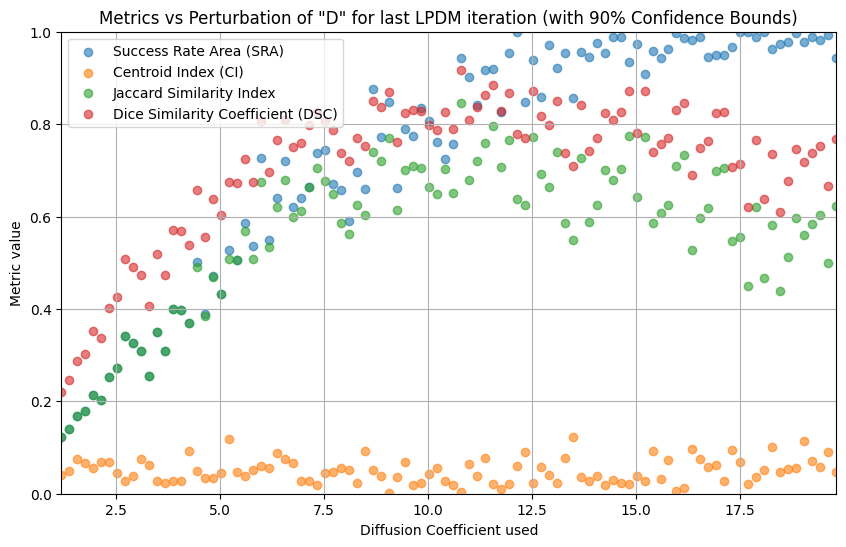

In [26]:
from scipy.optimize import curve_fit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

metrics_last_iteration = pd.read_csv('sa_2_4/heco_results_test_polygons_metrics_last_iteration.csv')

def power_law(x, a, b):
    return a * (x ** b)

# plot diagrams of metrics_last_iteration
#sort by perturbation distance
metrics_last_iteration = metrics_last_iteration.sort_values(by=['sim_diffusion_coefficient'], ascending=[True])

plt.figure(figsize=(10, 6))
plt.title('Metrics vs Perturbation of "D" for last LPDM iteration (with 90% Confidence Bounds)')
plt.xlabel('Diffusion Coefficient used')
plt.ylabel('Metric value')

variables = [
    ('SRA', 'Success Rate Area (SRA)', 'tab:blue'),
    ('CI', 'Centroid Index (CI)', 'tab:orange'),
    ('Jaccard', 'Jaccard Similarity Index', 'tab:green'),
    ('DICE', 'Dice Similarity Coefficient (DSC)', 'tab:red')
]

x_data = metrics_last_iteration['sim_diffusion_coefficient'].values
# avoid zero for power law
x_fit = np.linspace(max(0.1, x_data.min()), x_data.max(), 300)

for var, label, color in variables:
    y_data = metrics_last_iteration[var].values
    plt.scatter(x_data, y_data, label=label, color=color, alpha=0.6)
    
    # Fit power law trendline
    try:
        mask = (x_data > 0) & (y_data > 0)
        if np.sum(mask) > 2:
            popt, pcov = curve_fit(power_law, x_data[mask], y_data[mask], maxfev=10000)
            plt.plot(x_fit, power_law(x_fit, *popt), color=color, linestyle='--')
            
            # Calculate 90% confidence bounds using Monte Carlo sampling
            samples = np.random.multivariate_normal(popt, pcov, 1000)
            y_fits = np.array([power_law(x_fit, *s) for s in samples])
            lower_bound = np.percentile(y_fits, 30, axis=0)
            upper_bound = np.percentile(y_fits, 99.95, axis=0)
            plt.fill_between(x_fit, lower_bound, upper_bound, color=color, alpha=0.15)
    except Exception as e:
        print(f'Could not fit trendline for {var}: {e}')

plt.legend()
plt.ylim(0, 1)
plt.xlim(min(x_data),max(x_data))
plt.grid()
plt.savefig('sa_2_4/metrics_vs_origin_perturbation_last_iteration_bounds.png')
plt.show()
